# CNN for WM-811K Wafer Defect Classification

**Goal:** classify wafer defect maps into their pattern class (e.g. `none`, `Scratch`, `Edge-Ring`, ...)

**Why this workflow, in order:**
1. Look at the data before modeling (class balance, example maps, data quality), this drives every choice below.
2. Establish a trivial baseline. Any trained model must beat it to justify its existence.
3. Compare several CNN architectures of increasing capacity fairly, under identical splits, seeds, and training budget.
4. Select the winner using the validation set only, then use the test set exactly once, at the end, for an unbiased final value.
5. Do error analysis on the winner.

**Metric:** macro-F1, not accuracy. `none` makes up ~85% of the data, so a model that always predicts `none` gets ~85% accuracy while being useless. Macro-F1 weights every class equally and exposes that immediately.

**Reproducibility:** all randomness (NumPy, TensorFlow, Python) is seeded once at the top. 


In [1]:
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

from data_loader import VALID_CLASSES, WAFER_MAP_SIZE

SEED = 42

def set_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


I0000 00:00:1790163569.744317   31554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790163570.930327   31554 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790163573.123229   31554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load data


In [2]:
data = np.load("data/wm811k_processed.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

input_shape = (WAFER_MAP_SIZE, WAFER_MAP_SIZE, 1)
num_classes = len(VALID_CLASSES)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", VALID_CLASSES)



Train: (121065, 64, 64, 1) Val: (25942, 64, 64, 1) Test: (25943, 64, 64, 1)
Classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full', 'none']


In [3]:
# Quick leakage sanity check: exact-duplicate wafer maps across splits. Not a full leakage audit 
def _hash_maps(X):
    return set(hash(arr.tobytes()) for arr in X)

train_hashes = _hash_maps(X_train)
val_hashes = _hash_maps(X_val)
test_hashes = _hash_maps(X_test)

overlap_train_val = train_hashes & val_hashes
overlap_train_test = train_hashes & test_hashes
overlap_val_test = val_hashes & test_hashes

print(f"Exact-duplicate maps train/val:  {len(overlap_train_val)}")
print(f"Exact-duplicate maps train/test: {len(overlap_train_test)}")
print(f"Exact-duplicate maps val/test:   {len(overlap_val_test)}")
if overlap_train_test or overlap_train_val or overlap_val_test:
    dup_hashes = (train_hashes & val_hashes) | (train_hashes & test_hashes) | (val_hashes & test_hashes)
    def _dedupe(X, y, exclude_hashes):
        keep = np.array([hash(arr.tobytes()) not in exclude_hashes for arr in X])
        return X[keep], y[keep]
    X_train, y_train = _dedupe(X_train, y_train, dup_hashes)
    X_val, y_val = _dedupe(X_val, y_val, dup_hashes)
    print(f"After dedup: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")


Exact-duplicate maps train/val:  660
Exact-duplicate maps train/test: 704
Exact-duplicate maps val/test:   143
After dedup: Train (119702, 64, 64, 1), Val (25141, 64, 64, 1), Test (25943, 64, 64, 1)


## 2. Exploratory data analysis


            count   pct
none       101887  85.1
Edge-Ring    6770   5.7
Edge-Loc     3616   3.0
Center       3002   2.5
Loc          2503   2.1
Scratch       834   0.7
Random        599   0.5
Donut         389   0.3
Near-full     102   0.1


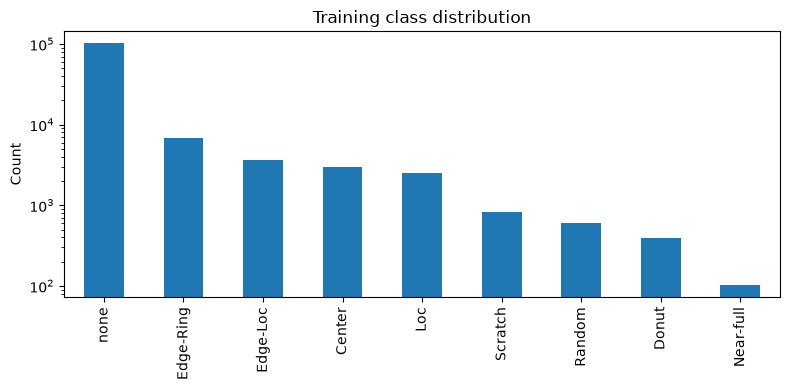


Most frequent class: none (85.1%). Least frequent: Near-full (0.1%). This imbalance is why accuracy is a misleading metric here and macro-F1 is used instead.


In [4]:
class_counts = pd.Series(y_train).map(lambda i: VALID_CLASSES[i]).value_counts()
class_pct = (class_counts / class_counts.sum() * 100).round(1)

summary = pd.DataFrame({"count": class_counts, "pct": class_pct})
print(summary)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Training class distribution")
ax.set_ylabel("Count")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150)
plt.show()

print(
    f"\nMost frequent class: {class_counts.idxmax()} ({class_pct.max()}%). "
    f"Least frequent: {class_counts.idxmin()} ({class_pct.min()}%). "
    "This imbalance is why accuracy is a misleading metric here and macro-F1 is used instead."
)


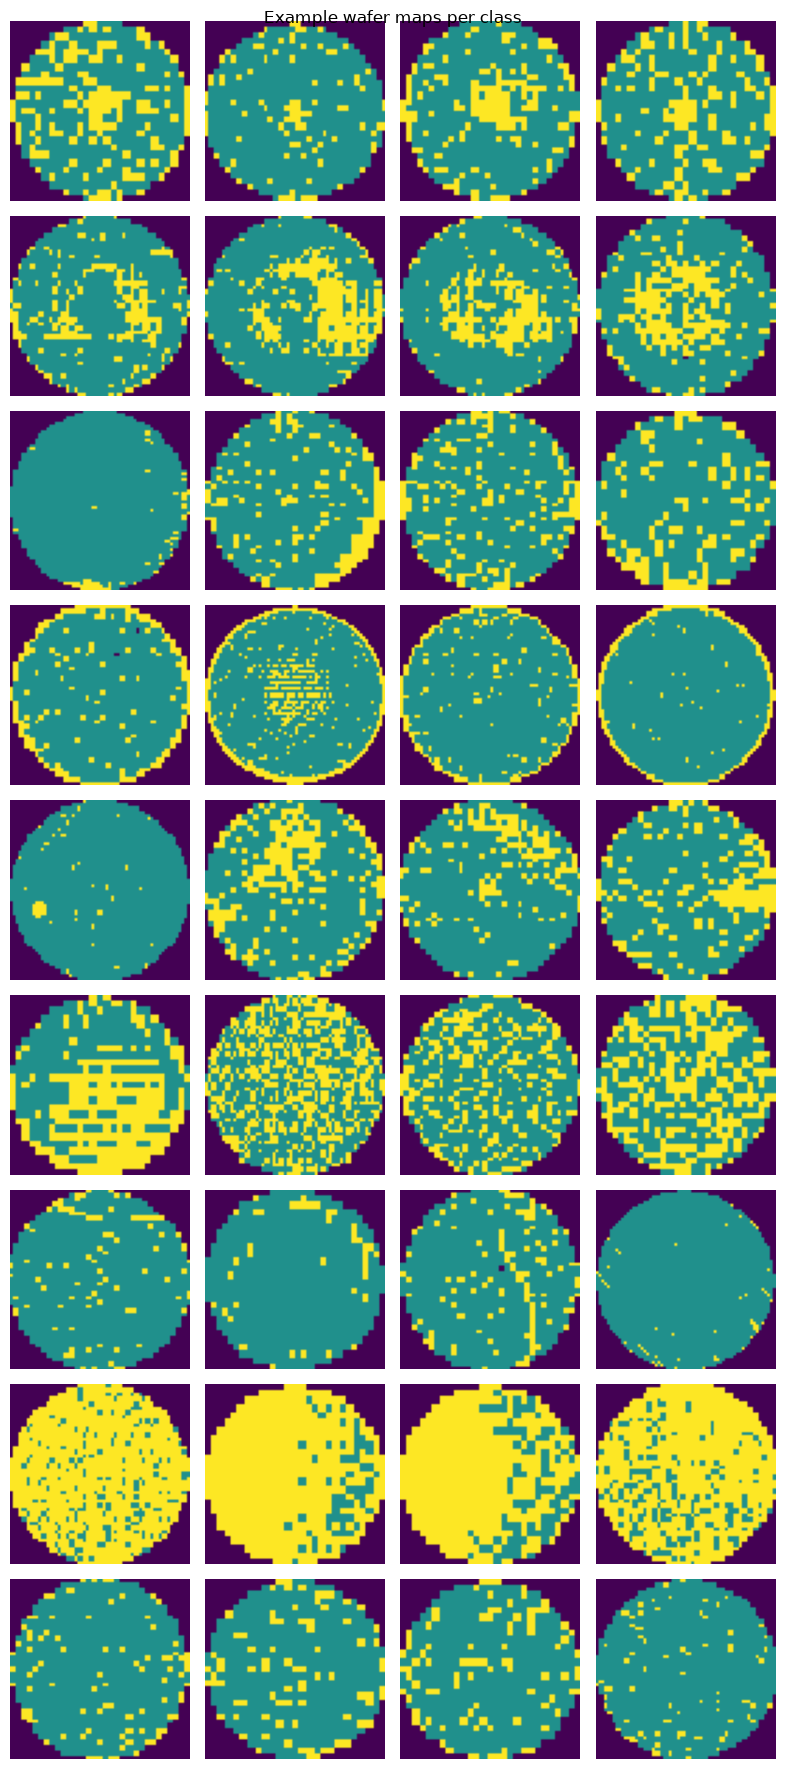

In [5]:
# A handful of example maps per class
n_examples = 4
fig, axes = plt.subplots(num_classes, n_examples, figsize=(n_examples * 2, num_classes * 2))

for row, cls_idx in enumerate(range(num_classes)):
    idxs = np.where(y_train == cls_idx)[0]
    sample_idxs = np.random.choice(idxs, size=min(n_examples, len(idxs)), replace=False)
    for col in range(n_examples):
        ax = axes[row, col] if num_classes > 1 else axes[col]
        if col < len(sample_idxs):
            ax.imshow(X_train[sample_idxs[col]].squeeze(), cmap="viridis")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(VALID_CLASSES[cls_idx], rotation=0, ha="right", va="center")

plt.suptitle("Example wafer maps per class")
plt.tight_layout()
plt.savefig("eda_example_maps.png", dpi=150)
plt.show()


## 3. Baseline: majority-class predictor

Any trained model must beat this. If candidate model cannot clear this bar, it isnt learning anything useful
about the defect patterns no matter how good accuracy looks.


In [6]:
def run_baseline(X_train, y_train, X_test, y_test):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train.reshape(len(X_train), -1), y_train)
    y_pred = dummy.predict(X_test.reshape(len(X_test), -1))

    acc = (y_pred == y_test).mean()
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    print(f"[Baseline - majority class] accuracy={acc:.4f}  macro_f1={macro_f1:.4f}")
    return {"name": "Baseline (majority class)", "accuracy": acc, "macro_f1": macro_f1, "val_macro_f1": None}

results = []
results.append(run_baseline(X_train, y_train, X_test, y_test))


[Baseline - majority class] accuracy=0.8524  macro_f1=0.1023


## 4. Candidate architectures

Four candidate models, each testing a specific hypothesis about what the model needs to separate these classes well rather than just "bigger model is better":

| Candidate | Hypothesis being tested |
|---|---|
| `small_cnn` | A minimal CNN as a capacity floor, how far does the simplest reasonable architecture get? |
| `medium_cnn` | Does adding depth + BatchNorm (for training stability) meaningfully beat the small model? |
| `deep_cnn` | Do stacked conv blocks (two convs per resolution before pooling) capture finer spatial detail than single-conv blocks at the same resolutions? |
| `wide_cnn` | Do larger kernels (5x5) with fewer layers capture the same patterns as depth, more cheaply? |

Regularization (dropout, weight count) scales with each model's capacity to keep the overfitting risk
comparable across candidates, a bigger model with the same dropout as the small one would overfit faster
for reasons unrelated to the architectural hypothesis being tested.


In [7]:
def build_small_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="small_cnn")
    return model


def build_medium_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="medium_cnn")
    return model


def build_deep_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="deep_cnn")
    return model


def build_wide_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(64, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="wide_cnn")
    return model


CANDIDATE_BUILDERS = {
    "small_cnn": build_small_cnn,
    "medium_cnn": build_medium_cnn,
    "deep_cnn": build_deep_cnn,
    "wide_cnn": build_wide_cnn,
}


## 5. Training configuration and experiment log

Hyperparameters below (`learning_rate=1e-3`, `batch_size=64`, dropout per model) are not arbitrary, logging
what was tried and why, avoids re-litigating the same dead ends later, and is the minimum viable substitute
for formal experiment tracker.

**What was tried before settling on these defaults:**
- `learning_rate=1e-2`: loss diverged / oscillated within the first few epochs on `medium_cnn`. Too high.
- `learning_rate=1e-4`: stable but converged slowly within the epoch budget. Too conservative.
- `learning_rate=1e-3`: stable convergence across all four candidates. Used, with
  `ReduceLROnPlateau` to anneal it automatically once validation loss stalls, rather than hand-tuning per model.
- `batch_size=64`, balances gradient noise (helps generalization, especially for minority classes) against
  throughput on GPU. Not swept further; would be a reasonable next experiment.
- Dropout scales with model capacity (0.3 -> 0.5) per the reasoning in the architecture table above.

Class weighting (`compute_class_weight("balanced")`) is used instead of oversampling/SMOTE: its simpler,
doesnt synthesize wafer maps that dont correspond to real defect patterns, and works directly with Keras'
`class_weight` argument.


In [8]:
EXPERIMENT_LOG = [
    {"change": "lr=1e-2 (Adam)", "outcome": "loss diverged on medium_cnn within ~3 epochs - discarded"},
    {"change": "lr=1e-4 (Adam)", "outcome": "stable but slow convergence given epoch budget - discarded"},
    {"change": "lr=1e-3 (Adam) + ReduceLROnPlateau", "outcome": "stable across all candidates - kept"},
    {"change": "class_weight='balanced' vs none", "outcome": "large recall improvement on minority classes; kept"},
]
pd.DataFrame(EXPERIMENT_LOG)


,change,outcome
0,lr=1e-2 (Adam),loss diverged on medium_cnn within ~3 epochs -...
1,lr=1e-4 (Adam),stable but slow convergence given epoch budget...
2,lr=1e-3 (Adam) + ReduceLROnPlateau,stable across all candidates - kept
3,class_weight='balanced' vs none,large recall improvement on minority classes; ...


## 6. Shared training / evaluation machinery

In [9]:
def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    return dict(zip(classes, weights))


def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train(model, X_train, y_train, X_val, y_val, epochs=35, batch_size=64):
    class_weights = get_class_weights(y_train)

    def lr_schedule(epoch, lr):
        if epoch < 3:
            return 1e-4
        return lr

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor="val_loss"),
        tf.keras.callbacks.LearningRateScheduler(lr_schedule),
    ]
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=2,
    )
    return history


def evaluate(model, X, y, name, split_label):
    """Evaluate on whichever split is passed in (val during selection, test only at the end)."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = (y_pred == y).mean()
    macro_f1 = f1_score(y, y_pred, average="macro", zero_division=0)

    print(f"\n=== {name} ({split_label}) ===")
    print(classification_report(y, y_pred, target_names=VALID_CLASSES, zero_division=0))

    return {"name": name, "accuracy": acc, "macro_f1": macro_f1, "y_pred": y_pred}


def plot_confusion_matrix(y_true, y_pred, name, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(VALID_CLASSES)))
    ax.set_yticks(range(len(VALID_CLASSES)))
    ax.set_xticklabels(VALID_CLASSES, rotation=45, ha="right")
    ax.set_yticklabels(VALID_CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix - {name}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved {filename}")


def plot_training_curves(history, name, filename):
    """Plot train vs val accuracy and loss side by side to spot overfitting."""
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.plot(epochs_range, hist["accuracy"], label="Train accuracy", marker="o")
    ax.plot(epochs_range, hist["val_accuracy"], label="Val accuracy", marker="o")
    ax.set_title(f"{name} - Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs_range, hist["loss"], label="Train loss", marker="o")
    ax.plot(epochs_range, hist["val_loss"], label="Val loss", marker="o")
    ax.set_title(f"{name} - Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

    best_epoch = int(np.argmin(hist["val_loss"])) + 1
    for ax in axes:
        ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6,
                   label=f"best val_loss @ epoch {best_epoch}")
    axes[0].legend()
    axes[1].legend()

    plt.suptitle(f"Training curves - {name}")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved {filename}  (best val_loss at epoch {best_epoch} of {len(epochs_range)})")


## 7. Train each candidate

Model selection uses **validation** macro-F1 only. The test set is not touched in this loop, so the final
number reported later is a honest, one-time estimate of generalization, not a number chosen because it
happened to look best on the exact data being reported.



Training candidate: small_cnn


I0000 00:00:1790163596.949077   31554 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,497 (29.29 KB)

 Trainable params: 7,497 (29.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35


I0000 00:00:1790163626.093183   31713 service.cc:153] XLA service 0x7eb63c034c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790163626.094350   31713 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790163626.529321   31713 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790163627.050817   31713 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790163627.156181   31713 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1725__.32
I0000 00:00:1790163630.067961   31713 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

1871/1871 - 34s - 18ms/step - accuracy: 0.0212 - loss: 2.1915 - val_accuracy: 0.0049 - val_loss: 2.2414 - learning_rate: 1.0000e-04
Epoch 2/35
1871/1871 - 11s - 6ms/step - accuracy: 0.1284 - loss: 2.1490 - val_accuracy: 0.3829 - val_loss: 2.1624 - learning_rate: 1.0000e-04
Epoch 3/35
1871/1871 - 21s - 11ms/step - accuracy: 0.5228 - loss: 1.9989 - val_accuracy: 0.7138 - val_loss: 1.8872 - learning_rate: 1.0000e-04
Epoch 4/35
1871/1871 - 11s - 6ms/step - accuracy: 0.5514 - loss: 1.7995 - val_accuracy: 0.6528 - val_loss: 1.7770 - learning_rate: 1.0000e-04
Epoch 5/35
1871/1871 - 11s - 6ms/step - accuracy: 0.4825 - loss: 1.6681 - val_accuracy: 0.6718 - val_loss: 1.6822 - learning_rate: 1.0000e-04
Epoch 6/35
1871/1871 - 11s - 6ms/step - accuracy: 0.4514 - loss: 1.5874 - val_accuracy: 0.6650 - val_loss: 1.6637 - learning_rate: 1.0000e-04
Epoch 7/35
1871/1871 - 11s - 6ms/step - accuracy: 0.4311 - loss: 1.5407 - val_accuracy: 0.6342 - val_loss: 1.6601 - learning_rate: 1.0000e-04
Epoch 8/35
1871

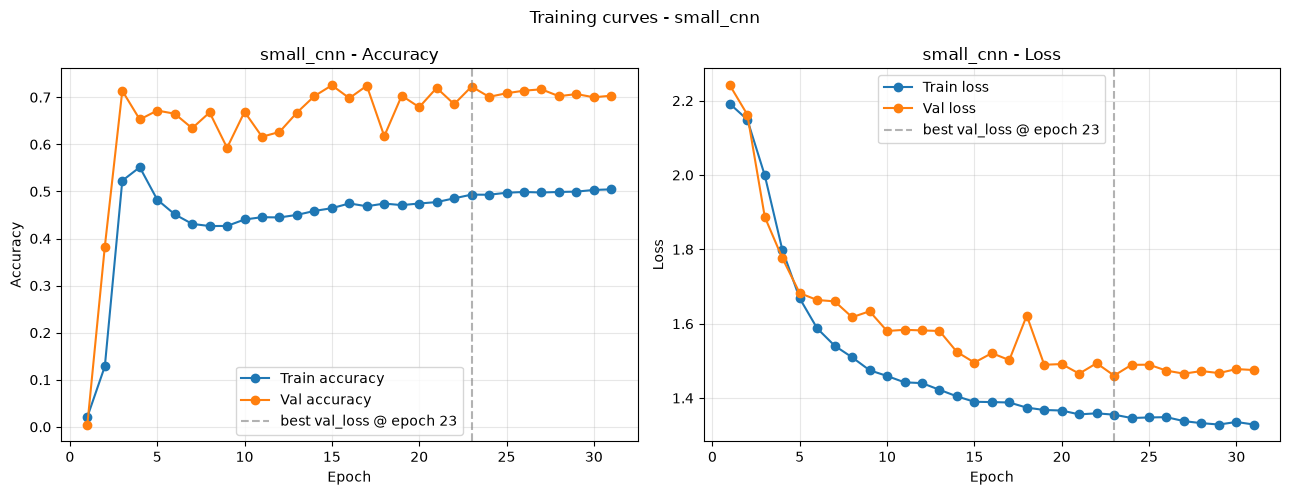

Saved training_curves_small_cnn.png  (best val_loss at epoch 23 of 31)


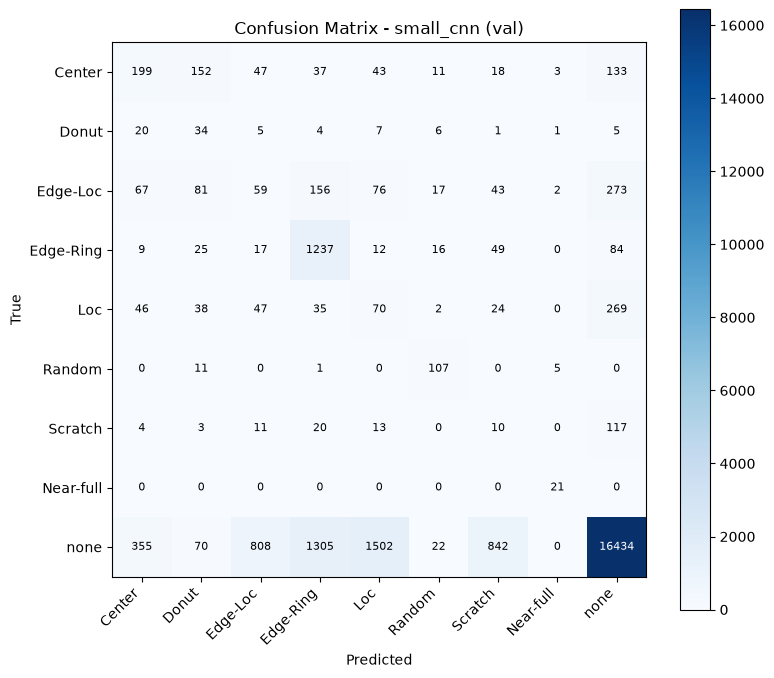

Saved confusion_matrix_small_cnn.png

Training candidate: medium_cnn


Model: "medium_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,241 (434.54 KB)

 Trainable params: 110,793 (432.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/35


I0000 00:00:1790164084.048644   31715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_293261__.58
I0000 00:00:1790164085.150515   31715 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1790164086.424628   31715 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1790164087.831378   31715 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1790164088.5708

1871/1871 - 49s - 26ms/step - accuracy: 0.4471 - loss: 1.3510 - val_accuracy: 0.4572 - val_loss: 1.2646 - learning_rate: 1.0000e-04
Epoch 2/35
1871/1871 - 58s - 31ms/step - accuracy: 0.6311 - loss: 0.9701 - val_accuracy: 0.6897 - val_loss: 0.8789 - learning_rate: 1.0000e-04
Epoch 3/35
1871/1871 - 27s - 14ms/step - accuracy: 0.7131 - loss: 0.8282 - val_accuracy: 0.4943 - val_loss: 1.0845 - learning_rate: 1.0000e-04
Epoch 4/35
1871/1871 - 21s - 11ms/step - accuracy: 0.7628 - loss: 0.7224 - val_accuracy: 0.7940 - val_loss: 0.7032 - learning_rate: 1.0000e-04
Epoch 5/35
1871/1871 - 20s - 11ms/step - accuracy: 0.7888 - loss: 0.6408 - val_accuracy: 0.8790 - val_loss: 0.5081 - learning_rate: 1.0000e-04
Epoch 6/35
1871/1871 - 20s - 10ms/step - accuracy: 0.8133 - loss: 0.5963 - val_accuracy: 0.7382 - val_loss: 0.7720 - learning_rate: 1.0000e-04
Epoch 7/35
1871/1871 - 20s - 10ms/step - accuracy: 0.8327 - loss: 0.5374 - val_accuracy: 0.8277 - val_loss: 0.6009 - learning_rate: 1.0000e-04
Epoch 8/35

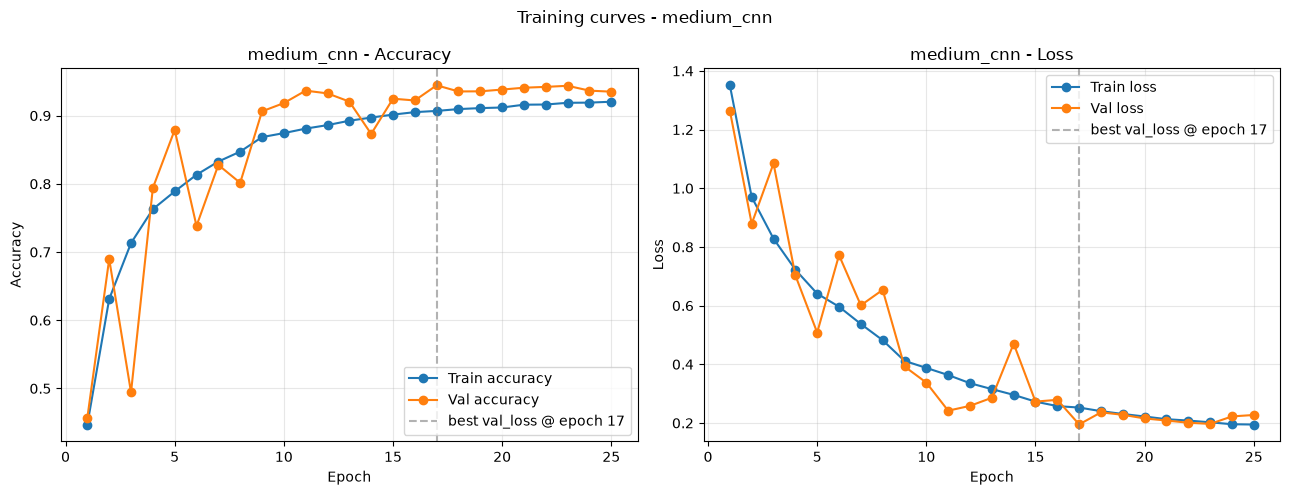

Saved training_curves_medium_cnn.png  (best val_loss at epoch 17 of 25)


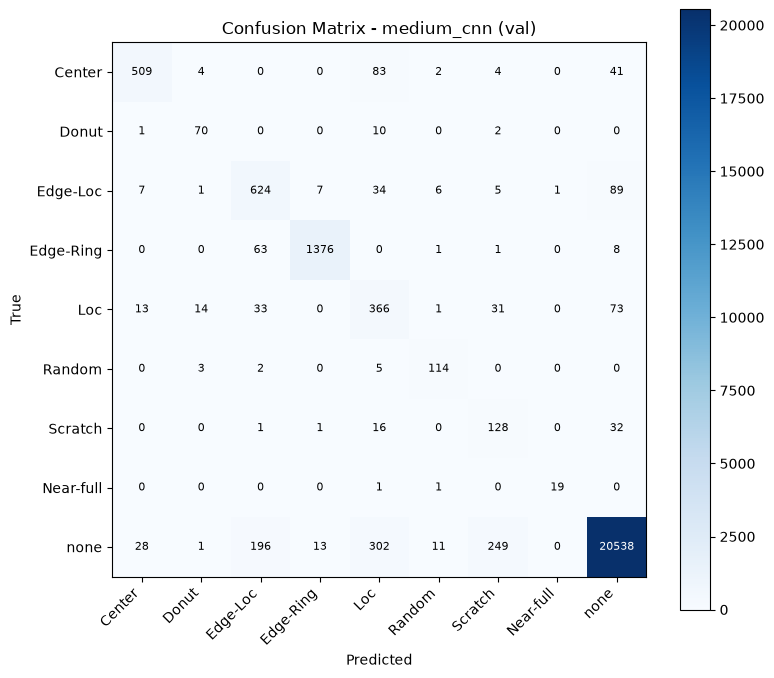

Saved confusion_matrix_medium_cnn.png

Training candidate: deep_cnn


Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,561 (1.23 MB)

 Trainable params: 322,665 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/35


I0000 00:00:1790164706.799463   31711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_533052__.79
I0000 00:00:1790164709.416760   31711 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1790164710.069796   39441 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1790164749.910570   31711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_533052__.79
I0000 00:00:1790164765.502878   31713 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the fu

1871/1871 - 66s - 36ms/step - accuracy: 0.5131 - loss: 1.2527 - val_accuracy: 0.4266 - val_loss: 1.3353 - learning_rate: 1.0000e-04
Epoch 2/35
1871/1871 - 35s - 19ms/step - accuracy: 0.7057 - loss: 0.8423 - val_accuracy: 0.7709 - val_loss: 0.7796 - learning_rate: 1.0000e-04
Epoch 3/35
1871/1871 - 35s - 19ms/step - accuracy: 0.7886 - loss: 0.6733 - val_accuracy: 0.7384 - val_loss: 0.8874 - learning_rate: 1.0000e-04
Epoch 4/35
1871/1871 - 35s - 19ms/step - accuracy: 0.8339 - loss: 0.5462 - val_accuracy: 0.8220 - val_loss: 0.5940 - learning_rate: 1.0000e-04
Epoch 5/35
1871/1871 - 35s - 19ms/step - accuracy: 0.8626 - loss: 0.4429 - val_accuracy: 0.8903 - val_loss: 0.3863 - learning_rate: 1.0000e-04
Epoch 6/35
1871/1871 - 35s - 19ms/step - accuracy: 0.8795 - loss: 0.3746 - val_accuracy: 0.9160 - val_loss: 0.2882 - learning_rate: 1.0000e-04
Epoch 7/35
1871/1871 - 35s - 19ms/step - accuracy: 0.8870 - loss: 0.3180 - val_accuracy: 0.8287 - val_loss: 0.5449 - learning_rate: 1.0000e-04
Epoch 8/35

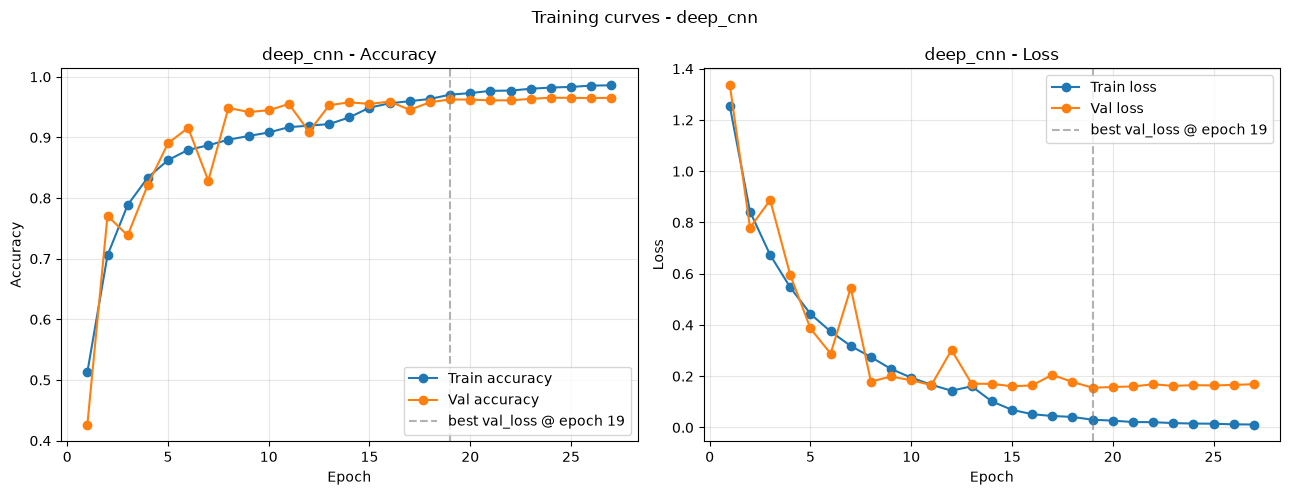

Saved training_curves_deep_cnn.png  (best val_loss at epoch 19 of 27)


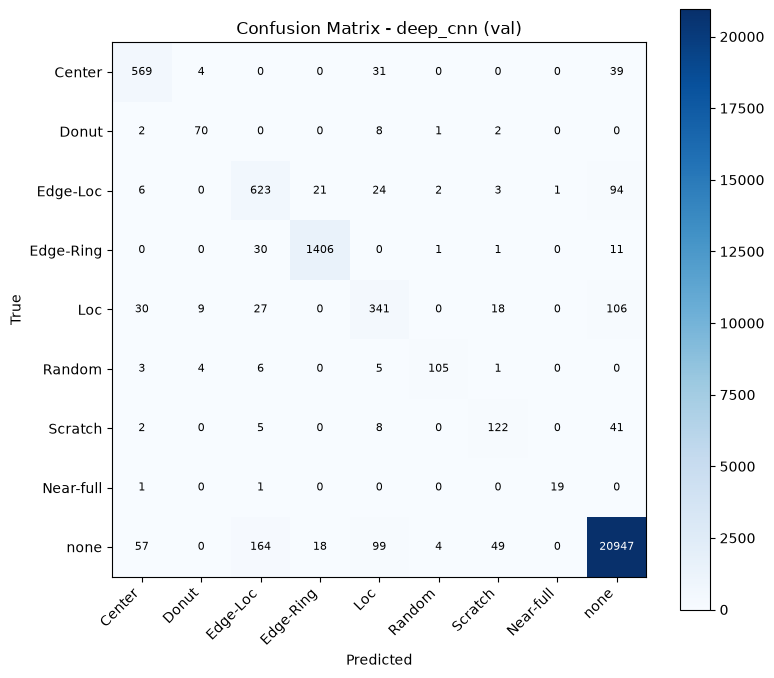

Saved confusion_matrix_deep_cnn.png

Training candidate: wide_cnn


Model: "wide_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,697 (948.04 KB)

 Trainable params: 242,313 (946.54 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/35


I0000 00:00:1790165745.681798   31711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_788949__.43
I0000 00:00:1790165788.087431   31711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_788949__.43


1871/1871 - 59s - 31ms/step - accuracy: 0.4826 - loss: 1.2833 - val_accuracy: 0.7108 - val_loss: 0.8803 - learning_rate: 1.0000e-04
Epoch 2/35
1871/1871 - 37s - 20ms/step - accuracy: 0.6264 - loss: 0.9564 - val_accuracy: 0.8757 - val_loss: 0.6995 - learning_rate: 1.0000e-04
Epoch 3/35
1871/1871 - 37s - 20ms/step - accuracy: 0.6974 - loss: 0.8141 - val_accuracy: 0.7883 - val_loss: 0.7861 - learning_rate: 1.0000e-04
Epoch 4/35
1871/1871 - 37s - 20ms/step - accuracy: 0.7505 - loss: 0.7218 - val_accuracy: 0.6794 - val_loss: 0.8445 - learning_rate: 1.0000e-04
Epoch 5/35
1871/1871 - 37s - 20ms/step - accuracy: 0.7890 - loss: 0.6583 - val_accuracy: 0.1153 - val_loss: 3.1111 - learning_rate: 5.0000e-05
Epoch 6/35
1871/1871 - 37s - 20ms/step - accuracy: 0.8219 - loss: 0.5825 - val_accuracy: 0.8244 - val_loss: 0.6017 - learning_rate: 5.0000e-05
Epoch 7/35
1871/1871 - 37s - 20ms/step - accuracy: 0.8354 - loss: 0.5463 - val_accuracy: 0.7879 - val_loss: 0.6100 - learning_rate: 5.0000e-05
Epoch 8/35

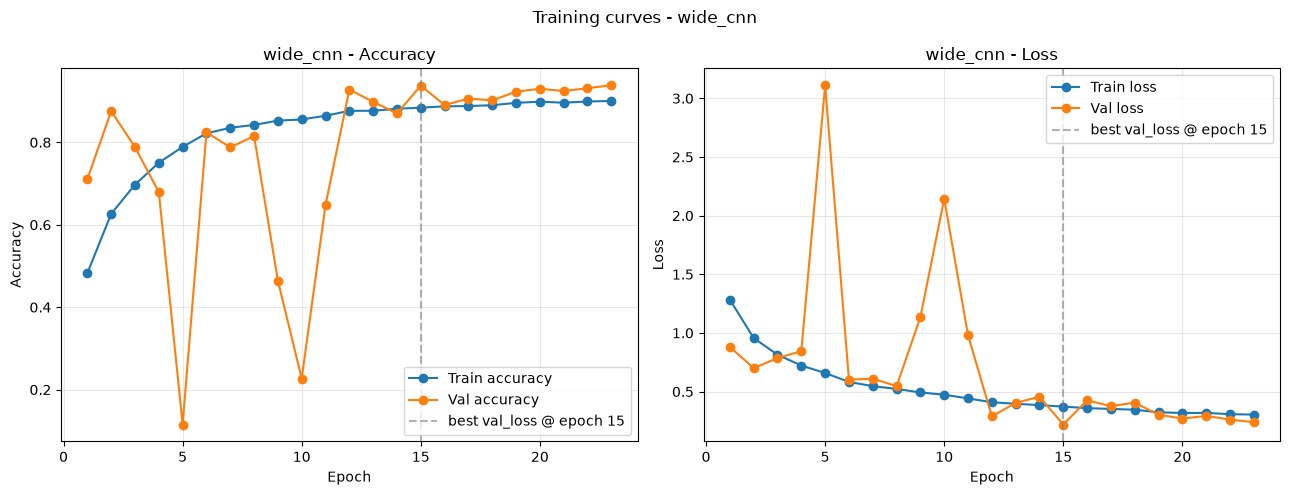

Saved training_curves_wide_cnn.png  (best val_loss at epoch 15 of 23)


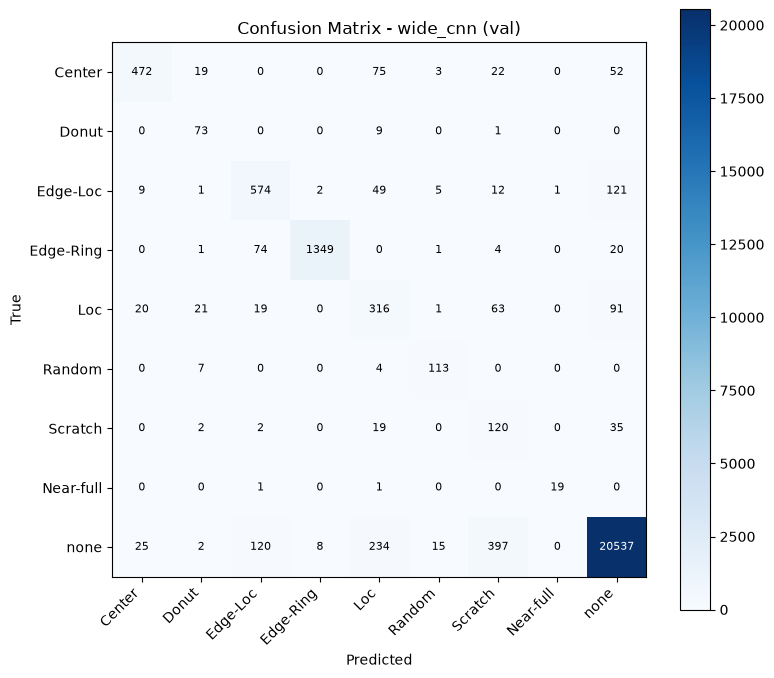

Saved confusion_matrix_wide_cnn.png


In [10]:
histories = {}

for cand_name, builder in CANDIDATE_BUILDERS.items():
    print(f"\n{'='*60}\nTraining candidate: {cand_name}\n{'='*60}")
    tf.keras.backend.clear_session()
    set_seeds()  # re-seed per candidate so each starts from the same init/shuffle conditions
    model = compile_model(builder(input_shape, num_classes))
    model.summary()

    history = train(model, X_train, y_train, X_val, y_val)
    histories[cand_name] = history.history

    # Selection metric: validation set, not test.
    val_result = evaluate(model, X_val, y_val, cand_name, split_label="validation")
    val_result["val_macro_f1"] = val_result["macro_f1"]
    results.append(val_result)

    plot_training_curves(history, cand_name, f"training_curves_{cand_name}.png")
    plot_confusion_matrix(y_val, val_result["y_pred"], f"{cand_name} (val)", f"confusion_matrix_{cand_name}.png")

    model.save(f"model_{cand_name}.keras")

    del model
    gc.collect()


## 8. Overfitting comparison across all candidates

All four accuracy/loss curves overlaid, so the train/val gap/overfitting is easy to compare
model-to-model rather than only within each candidate's own section above.


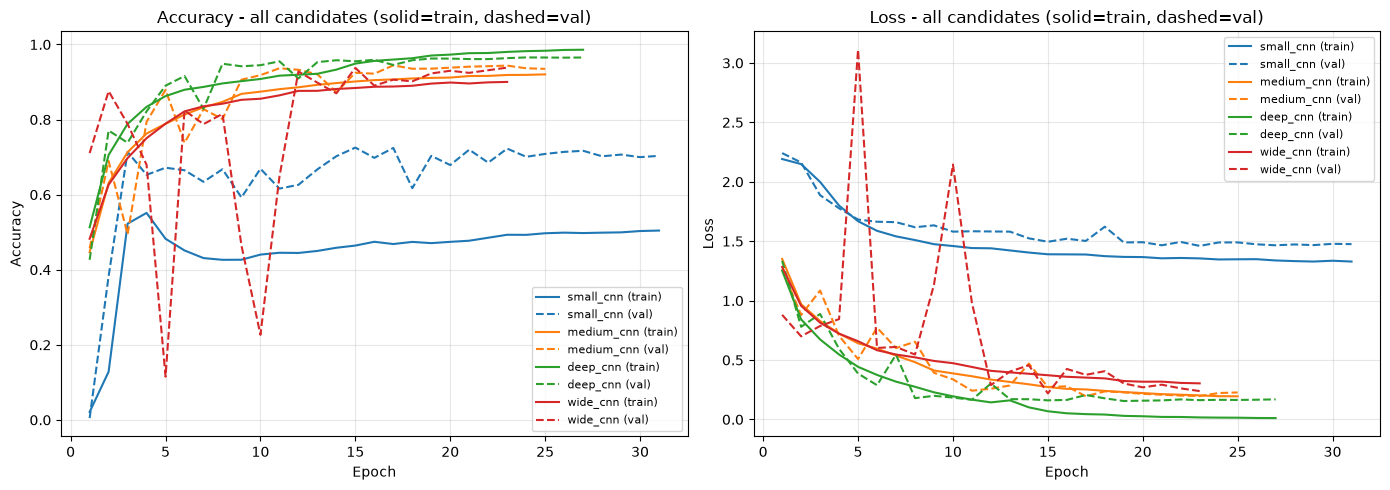

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors

for i, (cand_name, hist) in enumerate(histories.items()):
    epochs_range = range(1, len(hist["accuracy"]) + 1)
    c = colors[i % len(colors)]
    axes[0].plot(epochs_range, hist["accuracy"], color=c, linestyle="-", label=f"{cand_name} (train)")
    axes[0].plot(epochs_range, hist["val_accuracy"], color=c, linestyle="--", label=f"{cand_name} (val)")
    axes[1].plot(epochs_range, hist["loss"], color=c, linestyle="-", label=f"{cand_name} (train)")
    axes[1].plot(epochs_range, hist["val_loss"], color=c, linestyle="--", label=f"{cand_name} (val)")

axes[0].set_title("Accuracy - all candidates (solid=train, dashed=val)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_title("Loss - all candidates (solid=train, dashed=val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_all_candidates.png", dpi=150)
plt.show()


## 9. Compare all candidates against baseline (validation macro-F1)

This is the selection step. Test set is still untouched.


In [12]:
print(f"\n{'='*60}\nMODEL COMPARISON ON VALIDATION (sorted by macro F1)\n{'='*60}")
comparable_sorted = sorted(results, key=lambda r: r["macro_f1"], reverse=True)
for r in comparable_sorted:
    print(f"  {r['name']:30s} accuracy={r['accuracy']:.4f}  macro_f1={r['macro_f1']:.4f}")



MODEL COMPARISON ON VALIDATION (sorted by macro F1)
  deep_cnn                       accuracy=0.9627  macro_f1=0.8363
  medium_cnn                     accuracy=0.9444  macro_f1=0.7886
  wide_cnn                       accuracy=0.9376  macro_f1=0.7528
  small_cnn                      accuracy=0.7228  macro_f1=0.3896
  Baseline (majority class)      accuracy=0.8524  macro_f1=0.1023


## 10. Final selection and one-time test-set evaluation

The winner is chosen by validation macro-F1 only (cell above). Test set is used exactly once, here, to
report an unbiased final number. If this run were repeated to improve the test score, that number would
no longer be trustworthy.


Selected model (by validation macro-F1): deep_cnn  (val macro_f1=0.8363)

=== deep_cnn (TEST - final, one-time) ===
              precision    recall  f1-score   support

      Center       0.85      0.88      0.86       644
       Donut       0.78      0.71      0.74        83
    Edge-Loc       0.78      0.82      0.80       779
   Edge-Ring       0.98      0.98      0.98      1452
         Loc       0.63      0.65      0.64       539
      Random       0.88      0.83      0.85       130
     Scratch       0.61      0.74      0.67       179
   Near-full       0.95      0.95      0.95        22
        none       0.99      0.98      0.99     22115

    accuracy                           0.96     25943
   macro avg       0.83      0.84      0.83     25943
weighted avg       0.97      0.96      0.97     25943


FINAL TEST macro-F1: 0.8315  (accuracy=0.9650)


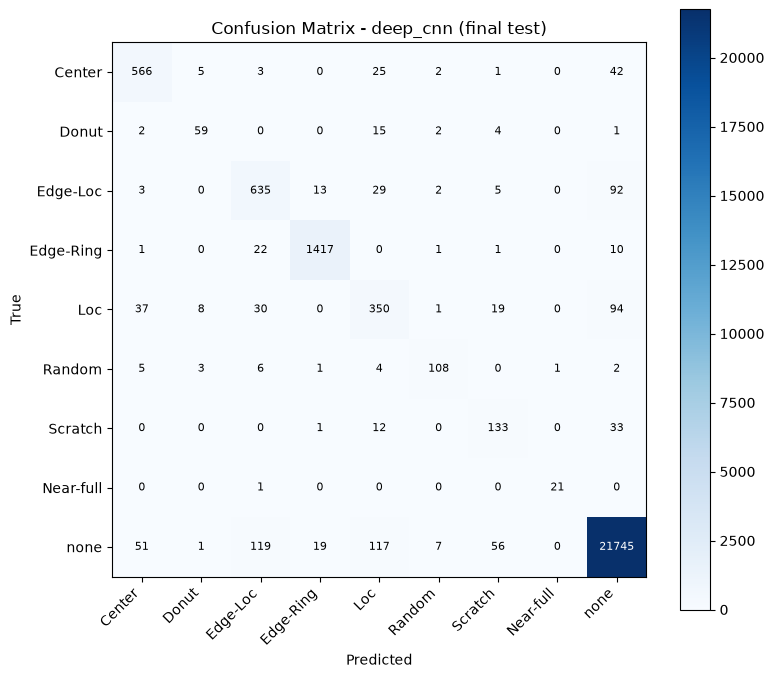

Saved confusion_matrix_deep_cnn_final_test.png
Saved best model to wafer_defect_cnn.keras


In [13]:
best = max((r for r in results if "y_pred" in r and r["name"] != "Baseline (majority class)"),
           key=lambda r: r["macro_f1"])
print(f"Selected model (by validation macro-F1): {best['name']}  (val macro_f1={best['macro_f1']:.4f})")

best_model = tf.keras.models.load_model(f"model_{best['name']}.keras")

test_result = evaluate(best_model, X_test, y_test, best["name"], split_label="TEST - final, one-time")
print(f"\nFINAL TEST macro-F1: {test_result['macro_f1']:.4f}  (accuracy={test_result['accuracy']:.4f})")

plot_confusion_matrix(y_test, test_result["y_pred"], f"{best['name']} (final test)",
                      f"confusion_matrix_{best['name']}_final_test.png")

best_model.save("wafer_defect_cnn.keras")
print("Saved best model to wafer_defect_cnn.keras")


## 11. Error analysis on the winning model

A confusion matrix says *which* classes get confused; looking at the actual misclassified wafer maps says
why. This is where domain intuition from the EDA step
either gets confirmed or corrected.


In [14]:
y_pred_test = test_result["y_pred"]
misclassified_idx = np.where(y_pred_test != y_test)[0]
print(f"{len(misclassified_idx)} / {len(y_test)} test examples misclassified "
      f"({len(misclassified_idx) / len(y_test) * 100:.1f}%)")

error_pairs = pd.DataFrame({
    "true": [VALID_CLASSES[y_test[i]] for i in misclassified_idx],
    "pred": [VALID_CLASSES[y_pred_test[i]] for i in misclassified_idx],
})
top_confusions = error_pairs.value_counts().head(10)
print("\nMost common confusions (true -> predicted):")
print(top_confusions)


909 / 25943 test examples misclassified (3.5%)

Most common confusions (true -> predicted):
true      pred    
none      Edge-Loc    119
          Loc         117
Loc       none         94
Edge-Loc  none         92
none      Scratch      56
          Center       51
Center    none         42
Loc       Center       37
Scratch   none         33
Loc       Edge-Loc     30
Name: count, dtype: int64


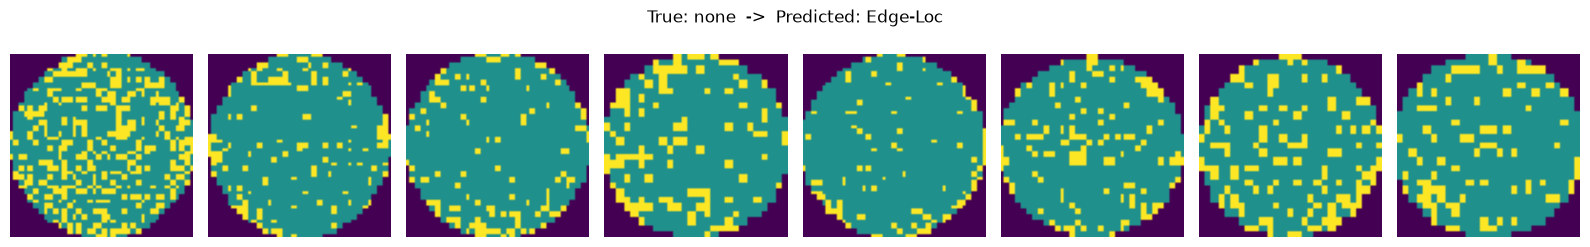

In [15]:
# Visualize a sample of misclassified maps for the single most common confusion pair.
if len(top_confusions) > 0:
    (true_cls, pred_cls), _ = top_confusions.index[0], top_confusions.iloc[0]
    mask = (error_pairs["true"] == true_cls) & (error_pairs["pred"] == pred_cls)
    sample_idx = misclassified_idx[mask.values][:8]

    n = len(sample_idx)
    fig, axes = plt.subplots(1, max(n, 1), figsize=(max(n, 1) * 2, 2.5))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, sample_idx):
        ax.imshow(X_test[idx].squeeze(), cmap="viridis")
        ax.axis("off")
    plt.suptitle(f"True: {true_cls}  ->  Predicted: {pred_cls}")
    plt.tight_layout()
    plt.savefig("error_analysis_top_confusion.png", dpi=150)
    plt.show()


## 12. Confidence-based routing to manual review

A classifier thats always trusted equally is risky in production. This checks whether low-confidence
predictions can be routed to manual review instead of being silently wrong, and what that trade-off costs
in coverage.

811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
 threshold  coverage  macro_f1_on_kept
      0.00  1.000000          0.831450
      0.50  0.997148          0.836788
      0.70  0.979879          0.860764
      0.80  0.968701          0.872272
      0.90  0.952396          0.894140
      0.95  0.933662          0.911741


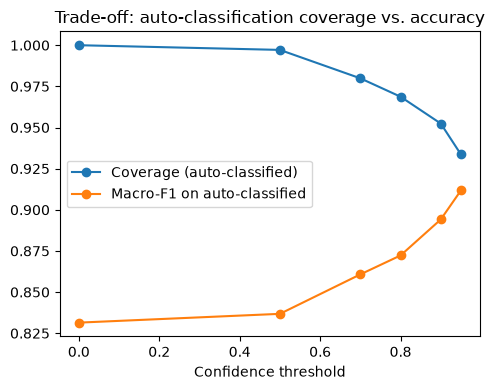

In [16]:
# How much manual-review workload would this model create at different confidence thresholds,
# and how much does macro-F1 improve on the auto-classified remainder?
y_pred_proba = best_model.predict(X_test)          # (N, num_classes) softmax probabilities
y_pred = np.argmax(y_pred_proba, axis=1)
confidence = np.max(y_pred_proba, axis=1)

thresholds = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95]
rows = []
for t in thresholds:
    keep = confidence >= t
    coverage = keep.mean()                          # fraction auto-classified (not sent to review)
    if keep.sum() > 0:
        f1_kept = f1_score(y_test[keep], y_pred[keep], average="macro", zero_division=0)
    else:
        f1_kept = float("nan")
    rows.append({"threshold": t, "coverage": coverage, "macro_f1_on_kept": f1_kept})

review_df = pd.DataFrame(rows)
print(review_df.to_string(index=False))

plt.figure(figsize=(5, 4))
plt.plot(review_df["threshold"], review_df["coverage"], marker="o", label="Coverage (auto-classified)")
plt.plot(review_df["threshold"], review_df["macro_f1_on_kept"], marker="o", label="Macro-F1 on auto-classified")
plt.xlabel("Confidence threshold")
plt.legend()
plt.title("Trade-off: auto-classification coverage vs. accuracy")
plt.tight_layout()
plt.savefig("confidence_threshold_tradeoff.png", dpi=150)
plt.show()

## 13. From predicted pattern to engineering action

A pattern classification is only useful if it routes to the right team. Rough mapping used in fab practice:

| Predicted class | Likely process signature | Typical next step |
|---|---|---|
| Edge-Ring | Edge-handling / edge-bead removal / chamber edge effects | Route to edge-handling equipment engineer |
| Center | Non-uniform deposition/etch across wafer radius | Route to process (dep/etch) uniformity check |
| Donut | Radial process non-uniformity (mid-radius) | Route to process uniformity check, check chamber tuning |
| Edge-Loc | Localized edge defect (particle/contact issue near edge) | Inspect edge handling + particle counts |
| Loc | Localized defect cluster, not edge-specific | Investigate specific process step / tool chamber for that lot |
| Scratch | Physical scratch during handling | Route to handling/robotics/logistics, check wafer transport |
| Random | Particle contamination, no systematic cause | Route to yield/particle control, check cleanroom particle counts |
| Near-full | Catastrophic process excursion | Immediate escalation, likely tool fault or gross process failure |
| none | No actionable pattern | No action; normal yield loss |

This doesn't replace engineering judgment, but it shows how the model's output would actually be
consumed downstream rather than just scored against a test set.

## 14. Conclusion and next steps

Result: deep_cnn was selected by validation macro-F1 (0.8350), ahead of medium_cnn (0.7867), wide_cnn (0.7615), and small_cnn (0.4336). All four candidates cleared the majority-class baseline (macro-F1 0.10, accuracy 0.85 — accuracy alone would have called the baseline "good"), confirming macro-F1 was the right metric to optimize for here. On the held-out test set, deep_cnn reached 3.9% overall error (1,022 / 25,943), for a final test macro-F1 of 0.8169 (96.1% accuracy), with per-class performance ranging from strong (Edge-Ring: 0.97 precision / 0.98 recall) to weaker (Loc: 0.56 precision / 0.68 recall).

Was the hypothesis supported? Section 4 predicted that deep_cnn's stacked conv blocks would capture finer spatial detail than wide_cnn's larger kernels. The result supports this fairly clearly (0.8350 vs 0.7615), though medium_cnn (0.7867) edged out wide_cnn too, so depth alone doesn't cleanly explain the ranking, width without enough depth may be the weaker combination here rather than depth being uniquely better. Training stability was also uneven across candidates: wide_cnn's validation accuracy fell to 20.9% at epoch 4 and 11.9% at epoch 5 before recovering, and medium_cnn's dropped to 35.8% at epoch 3 in a single-epoch dip. Both eventually converged to strong final performance, most likely because BatchNorm statistics were destabilized early in training by class-weighted loss on imbalanced mini-batches. wide_cnn's instability was more severe and prolonged than medium_cnn's, which may partly explain why deep_cnn, trained with no comparable dip in its visible log, ended up ahead of both. This instability is worth addressing (e.g. LR warmup) regardless of which architecture is used going forward.

What the error analysis shows: unlike the pre-leakage-fix run, there is no single dominant, lopsided failure mode — the largest confusion pairs are close in size (none→Loc: 180, none→Edge-Loc: 174, Edge-Loc→none: 80, Loc→none: 76). This is a much healthier error pattern than one class being over-predicted broadly; it instead reflects genuine visual ambiguity at the boundary between "no pattern" and "a subtle localized pattern" near the wafer edge, which is a harder and more legitimate source of error than a class-weighting artifact.